In [2]:
pip install geopandas 

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
    --------------------------------------- 0.5/22.9 MB 699.0 kB/s eta 0:00:33
    --------------------------------------- 0.5/22.9 MB 699.0 kB/s eta 0:00:33
   - -------------------------------------- 0.8/22.9 MB 730.2 kB/s eta 0:00:31
   - -------------------------------------- 1.0/22.9 MB 762.8 kB/s eta 0:00:29
   - -------------------------------------- 1.0/22.9 MB 762.8 kB/s eta 0:00:29
   -- ------------------------------------- 1.3/22.9 MB 721.7 kB/s eta 0:00:30
   -- ------------------------------------- 1.3/22.9 MB 721.7 kB/s eta 0:00:30
   -- ------------------------------------- 1.6/22.9 MB 717.0 kB/s eta 0:00:30
   -- ------------------------------------- 1.6/22.9 MB 717.0 kB/s eta 0:00:30
   --- --

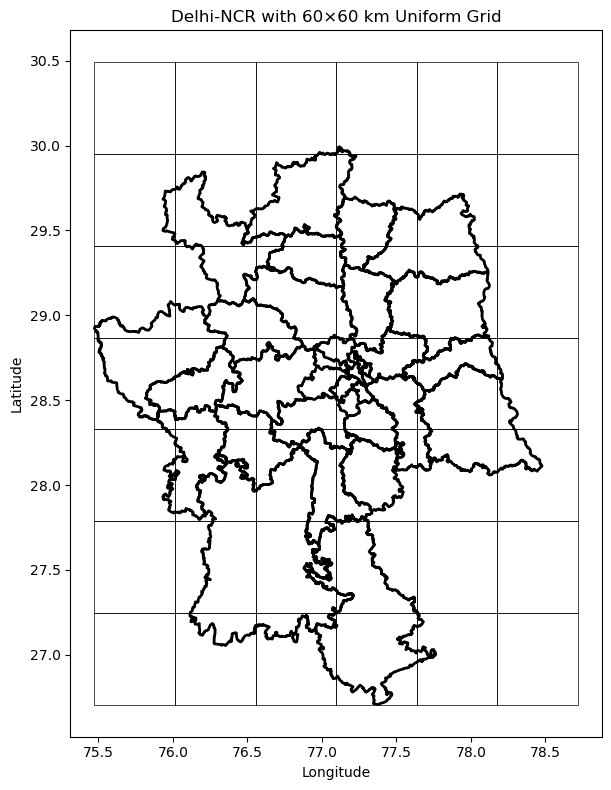

✅ Plot saved to: C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations/delhi_ncr_with_60km_grid.png


In [1]:
"""
Q1. Spatial Reasoning & Data Filtering
   i)Plot the Delhi-NCR shapefile and overlay a 60×60 km uniform grid
"""

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box

#Load File and read it 
delhi_ncr_path = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\shapefiles\delhi_ncr_region.geojson"
delhi_ncr = gpd.read_file(delhi_ncr_path)

#boubding of longitute and latitude (min and max) basically used for deciding corrdinates to draw the grid
minx, miny, maxx, maxy = delhi_ncr.total_bounds



#  Define grid size   60 km ≈ 60 / 111 ≈ 0.54 degrees (according to EPSG:4326) [1 degree= 111km]

grid_size_deg = 60 / 111.0  


#  Create uniform grid

grid_cells = [] # empty list initialise to store individual grid box

x_coords = np.arange(minx, maxx, grid_size_deg) # arrange evenly spced values in vertical lines
y_coords = np.arange(miny, maxy, grid_size_deg) # arrange evenly spced values in vertical lines

for x in x_coords:  # this loop is for generating each grid cell of 60x60 km
    for y in y_coords:
        cell = box(
            x,
            y,
            x + grid_size_deg,
            y + grid_size_deg
        )
        grid_cells.append(cell) # add each grid cell to the list

grid = gpd.GeoDataFrame( # now the dataframe is converted to geospatial data for better visualisation in lines rather than numbers 
    geometry=grid_cells,
    crs="EPSG:4326"
)


#  Plot NCR boundary and grid
fig, ax = plt.subplots(figsize=(8, 8))

delhi_ncr.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2,
    label="Delhi-NCR Boundary"
)

grid.plot(
    ax=ax,
    facecolor="none",
    linewidth=0.5,
    label="60×60 km Grid"
)

ax.set_title("Delhi-NCR with 60×60 km Uniform Grid", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()

#output is saved in visualisation folder 

output_path = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\Visualizations/delhi_ncr_with_60km_grid.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("✅ Plot saved to:", output_path)

In [14]:

# ii) Filter satellite images whose center coordinates fall inside Delhi-NCR
import os
from shapely.geometry import Point

image_dir = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\raw\satellite\images\rgb"
image_files = [f for f in os.listdir(image_dir) if f.endswith(".png")]

total_images = len(image_files) # give total image present in the folder

image_points = [] # list for points 
image_names = []  # list for names

for img in image_files:
    name = img.replace(".png", "")  # since the image name has the lat and long, the split from undescore and removing .png will give the info
    lat_str, lon_str = name.split("_")

    lat = float(lat_str)  # convert string to numeric 
    lon = float(lon_str)

    image_names.append(img)
    image_points.append(Point(lon, lat))  # (lon, lat) order


image_gdf = gpd.GeoDataFrame(
    {"image_name": image_names},
    geometry=image_points,
    crs="EPSG:4326"
)

# main filtering of ncr and outside ncr is been done here 
inside_mask = image_gdf.within(delhi_ncr.unary_union)  # the unary_unio merges all the ncr polygon and within funtion checks true or false for inside ncr.
filtered_images = image_gdf[inside_mask] # all true images are saved here 

# saving metadata
output_path = r"C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\processed\filtered_image\filtered_image_centers.csv"
filtered_images.drop(columns="geometry").to_csv(output_path, index=False)  # removes geometry column as it is csv file 
print("Filtered image saved to:", output_path)


C:\Users\apurb_oi8roye\AppData\Local\Temp\ipykernel_20592\3894719746.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  inside_mask = image_gdf.within(delhi_ncr.unary_union)  # the unary_unio merges all the ncr polygon and within funtion checks true or false for inside ncr.


Filtered image saved to: C:\Users\apurb_oi8roye\Desktop\Earth_Observation\Earth_Observation\data\processed\filtered_image\filtered_image_centers.csv


In [16]:
filtered_images.head()

,image_name,geometry
0,28.2056_76.8558.png,POINT (76.8558 28.2056)
1,28.2056_76.8646.png,POINT (76.8646 28.2056)
2,28.2056_76.8734.png,POINT (76.8734 28.2056)
3,28.2056_76.8822.png,POINT (76.8822 28.2056)
4,28.2056_76.8910.png,POINT (76.891 28.2056)


In [15]:
# iii) Report the total number of images before and after filtering.

print("Total images before filtering:", len(image_gdf))
print("Total images after filtering:", len(filtered_images))


Total images before filtering: 9216
Total images after filtering: 8015
